# Bank Finance Report

**Report Date:** 2026-06-30 | **Currency:** PLN | **Audience:** Finance / Treasury

---
| # | Section |
|---|---|
| — | Executive P&L Summary |
| 1 | Interest Income & Expense Waterfall |
| 2 | Product Margin Analysis |
| 3 | Funding Cost Structure |
| 4 | Fixed vs Variable Rate Exposure |
| 5 | NII Bridge — Locked Interest vs Renewal |
| 6 | Repricing Profile |
| 7 | Rate Sensitivity (Business View) |
| 8 | Economic Profit (EP) — Total & Per-Product |


In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from sqlalchemy import create_engine, text
from IPython.display import HTML, display

ENGINE = create_engine(
    'mssql+pyodbc://maciek_d/bank_gen'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&Trusted_Connection=yes',
    future=True,
)
REPORT_DATE = pd.to_datetime('2026-06-30')
CCY = 'PLN'

plt.rcParams.update({
    'figure.dpi': 100, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.35, 'grid.linestyle': '--',
    'font.size': 9, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
    'axes.titlepad': 8, 'legend.fontsize': 8, 'legend.framealpha': 0.8,
})

C_INC = '#2E7D32'; C_EXP = '#C62828'; C_NET = '#1565C0'
C_REN = '#0288D1'; C_FIX = '#1B5E20'; C_VAR = '#F57F17'
C_ADM = '#78909C'; C_GR  = '#455A64'

PRODUCT_COLORS = {
    'Mortgage Fixed':       '#1565C0',
    'Mortgage Float':       '#42A5F5',
    'Consumer Loan Fixed':  '#2E7D32',
    'Consumer Loan Float':  '#66BB6A',
    'Bond / Securities':    '#F57F17',
    'Interbank / Other':    '#78909C',
    'Term Deposit':         '#B71C1C',
    'Savings Account':      '#EF5350',
    'Current Account':      '#FF8A65',
    'Issued Bond':          '#8D6E63',
}

def rsql(q, **p):
    return pd.read_sql_query(text(q), ENGINE, params=p)

def tkey(lbl):
    if lbl == '1D':   return 0
    if lbl == '>30Y': return 999_999
    if lbl.endswith('Y'): return int(lbl[:-1]) * 12
    if lbl.endswith('M'): return int(lbl[:-1])
    return 99_999

def pct_fmt(v, _=None): return f'{v:.1f}%'

PROD_LABELS = {
    '0000': 'Interbank / Other',
    '1000': 'Mortgage Fixed',        '1100': 'Mortgage Float',
    '2000': 'Consumer Loan Fixed',   '2100': 'Consumer Loan Float',
    '3000': 'Bond / Securities',     '3100': 'Bond / Securities',
    '3200': 'T-Bill',                '3500': 'Cash / Central Bank',
    '4100': 'SME Investment Loan',   '5000': 'Issued Bond',
    '6000': 'Current Account',       '6300': 'Current Account (SME)',
    '7060': 'Term Deposit',          '7900': 'Interbank Placement',
    '8000': 'Savings Account',
}

# ── Shared HTML table renderer (used instead of raw print() tables) ──────────
_TBL_HEAD_BG  = '#37474F'
_TBL_ROW_ALT  = '#f4f6f7'
_TBL_BORDER   = '#d5dbde'
_TBL_FONT     = "font-family:'Segoe UI', Arial, sans-serif;"

def html_table(headers, rows, aligns=None, total_row=None, title=None, note=None):
    """Render a list-of-rows table (already-formatted strings) as styled HTML.

    headers    : list[str]
    rows       : list[list[str]]   -- pre-formatted cell text, one list per row
    aligns     : list['left'|'right'|'center'], defaults to left col0 + right rest
    total_row  : optional list[str] rendered bold with a top border
    title      : optional bold caption above the table
    note       : optional small grey footnote below the table
    """
    n = len(headers)
    aligns = aligns or (['left'] + ['right'] * (n - 1))

    def _th(i):
        return (f'<th style="text-align:{aligns[i]};padding:7px 14px;'
                f'background:{_TBL_HEAD_BG};color:#ffffff;font-weight:600;'
                f'font-size:12.5px;{_TBL_FONT}white-space:nowrap;">{headers[i]}</th>')

    def _td(i, v, bold=False, top_border=False, color=None):
        style = (f'text-align:{aligns[i]};padding:5px 14px;font-size:12.5px;'
                 f'{_TBL_FONT}white-space:nowrap;')
        if bold: style += 'font-weight:700;'
        if top_border: style += f'border-top:2px solid {_TBL_HEAD_BG};'
        if color: style += f'color:{color};'
        return f'<td style="{style}">{v}</td>'

    parts = ['<div style="overflow-x:auto;margin:6px 0 4px 0;">']
    if title:
        parts.append(f'<div style="{_TBL_FONT}font-weight:700;font-size:13.5px;'
                      f'margin-bottom:4px;">{title}</div>')
    parts.append(f'<table style="border-collapse:collapse;border:1px solid {_TBL_BORDER};">')
    parts.append('<thead><tr>' + ''.join(_th(i) for i in range(n)) + '</tr></thead>')
    parts.append('<tbody>')
    for ridx, row in enumerate(rows):
        bg = '#ffffff' if ridx % 2 == 0 else _TBL_ROW_ALT
        cells = []
        for i, cell in enumerate(row):
            if isinstance(cell, tuple):
                v, color = cell
            else:
                v, color = cell, None
            cells.append(_td(i, v, color=color))
        parts.append(f'<tr style="background:{bg};">' + ''.join(cells) + '</tr>')
    if total_row:
        cells = []
        for i, cell in enumerate(total_row):
            v, color = cell if isinstance(cell, tuple) else (cell, None)
            cells.append(_td(i, v, bold=True, top_border=True, color=color))
        parts.append(f'<tr style="background:#eceff1;">' + ''.join(cells) + '</tr>')
    parts.append('</tbody></table>')
    if note:
        parts.append(f'<div style="{_TBL_FONT}font-size:11px;color:#607D8B;'
                      f'margin-top:4px;">{note}</div>')
    parts.append('</div>')
    return HTML(''.join(parts))

def pos_neg(v, fmt):
    """Format a signed number and color it green if >=0 else red."""
    s = format(v, fmt)
    return (s, '#2E7D32' if v >= 0 else '#C62828')

print(f'Setup complete  |  {REPORT_DATE.date()}  |  {CCY}')


Setup complete  |  2026-06-30  |  PLN


## Data Loading

In [2]:
RD = REPORT_DATE

# 1. Actual book balances per product
bs_prod = rsql('''
    SELECT product_code, product_name, bs_side, currency,
           SUM(balance_amt) AS balance_amt
    FROM dbo.transactions
    WHERE report_date = :rd AND currency = :ccy
    GROUP BY product_code, product_name, bs_side, currency
''', rd=RD, ccy=CCY)

equity_amt = float(rsql(
    'SELECT ISNULL(SUM(balance_amt),0) AS v FROM schemat.equity WHERE report_date=:rd',
    rd=RD)['v'].iloc[0])

# 2. NII by product — CF base scenario (consistent fixed pipeline)
nii_prod = rsql('''
    SELECT product_code, bs_side, rate_type,
           SUM(nii_interest) AS nii_interest,
           SUM(nii_renewal)  AS nii_renewal,
           SUM(nii_total)    AS nii_total
    FROM cf.nii_base_scenario
    WHERE report_date = :rd AND currency = :ccy AND scenario_id = 'base'
    GROUP BY product_code, bs_side, rate_type
''', rd=RD, ccy=CCY)

# 3. Balance-weighted average rates per product
rate_prod = rsql('''
    SELECT product_code, bs_side,
           SUM(beh_outstanding * client_rt)    / NULLIF(SUM(beh_outstanding), 0) AS avg_client_rt,
           SUM(beh_outstanding * margin)        / NULLIF(SUM(beh_outstanding), 0) AS avg_margin,
           SUM(beh_outstanding * ren_client_rt) / NULLIF(SUM(beh_outstanding), 0) AS avg_ren_rt
    FROM cf.nii_base_scenario
    WHERE report_date = :rd AND currency = :ccy AND scenario_id = 'base'
      AND beh_outstanding > 0
    GROUP BY product_code, bs_side
''', rd=RD, ccy=CCY)

# 4. Scenario NII for rate sensitivity
nii_scen = rsql('''
    SELECT scenario_id, currency,
           SUM(nii_interest) AS nii_interest,
           SUM(nii_renewal)  AS nii_renewal,
           SUM(nii_total)    AS nii_total
    FROM irrbb.nii_results WHERE report_date=:rd AND currency=:ccy
    GROUP BY scenario_id, currency
''', rd=RD, ccy=CCY)

# 5. Repricing gap
try:
    ir_gap = rsql('''
        SELECT currency, tenor_bucket, bucket_start_dt, bucket_end_dt,
               gap_cf, ISNULL(gap_cf_ca, 0) AS gap_cf_ca
        FROM irrbb.ir_gap_beh WHERE currency = :ccy
    ''', ccy=CCY)
except Exception:
    ir_gap = rsql('''
        SELECT currency, tenor_bucket, bucket_start_dt, bucket_end_dt,
               gap_cf, 0.0 AS gap_cf_ca
        FROM irrbb.ir_gap_beh WHERE currency = :ccy
    ''', ccy=CCY)

# ── Master product table ──────────────────────────────────────────────────────
prod = (nii_prod
        .merge(rate_prod, on=['product_code','bs_side'], how='left')
        .merge(bs_prod[['product_code','bs_side','balance_amt']], on=['product_code','bs_side'], how='left'))
prod['label']       = prod['product_code'].map(PROD_LABELS).fillna(prod['product_code'])
prod['balance_amt'] = prod['balance_amt'].fillna(0.0)
assets_p = prod[prod['bs_side'] == 'A'].copy()
liabs_p  = prod[prod['bs_side'] == 'L'].copy()

# ── Key aggregate metrics ─────────────────────────────────────────────────────
total_assets   = float(bs_prod[bs_prod['bs_side']=='A']['balance_amt'].sum())
total_liabs    = float(bs_prod[bs_prod['bs_side']=='L']['balance_amt'].sum())
total_inc      = float(assets_p['nii_interest'].sum())
total_exp      = abs(float(liabs_p['nii_interest'].sum()))
nii_total      = total_inc - total_exp
nim_pct        = nii_total  / total_assets * 100 if total_assets else 0
avg_asset_yld  = total_inc  / total_assets * 100 if total_assets else 0
avg_cost_funds = total_exp  / total_liabs  * 100 if total_liabs  else 0
int_spread     = avg_asset_yld - avg_cost_funds

print(f'Data loaded  |  {len(prod)} product rows  |  '
      f'assets {total_assets/1e9:.2f}B / liabs {total_liabs/1e9:.2f}B PLN')


Data loaded  |  17 product rows  |  assets 10.00B / liabs 8.80B PLN


---
## Executive P&L Summary


In [3]:
_base_nii_off = float(nii_scen[nii_scen['scenario_id']=='base']['nii_total'].sum())                 if not nii_scen.empty else nii_total

display(html_table(
    ['Balance Sheet', 'Value'],
    [
        ['Total assets',      f'{total_assets/1e9:.2f}  B PLN'],
        ['Total liabilities', f'{total_liabs/1e9:.2f}  B PLN'],
        ['Equity',            f'{equity_amt/1e9:.2f}  B PLN'],
    ],
    title=f'FINANCE P&L SUMMARY  |  {CCY}  |  {REPORT_DATE.date()}',
))

display(html_table(
    ['Interest Income & Expense (1-year horizon, existing book)', 'Value'],
    [
        ['Interest income (assets)', pos_neg(total_inc/1e6,  '+9.1f')],
        ['Interest expense (liab.)', pos_neg(-total_exp/1e6, '+9.1f')],
    ],
    total_row=['Net Interest Income', pos_neg(nii_total/1e6, '+9.1f')],
    note='M PLN',
))

display(html_table(
    ['Margin Metrics', 'Value'],
    [
        ['Net Interest Margin (NII / total assets)', f'{nim_pct:.2f} %'],
        ['Avg asset yield',                            f'{avg_asset_yld:.2f} %'],
        ['Avg cost of funds',                          f'{avg_cost_funds:.2f} %'],
        ['Interest spread',                            f'{int_spread:.2f} %'],
    ],
))

_fa = prod[(prod['bs_side']=='A') & (prod['rate_type']=='F')]['balance_amt'].sum()
_va = prod[(prod['bs_side']=='A') & (prod['rate_type']=='V')]['balance_amt'].sum()
_fl = prod[(prod['bs_side']=='L') & (prod['rate_type']=='F')]['balance_amt'].sum()
_vl = prod[(prod['bs_side']=='L') & (prod['rate_type']=='V')]['balance_amt'].sum()
_al = prod[(prod['bs_side']=='L') & (prod['rate_type']=='A')]['balance_amt'].sum()
display(html_table(
    ['Rate Type Mix (by balance)', 'Fixed', 'Variable', 'Admin'],
    [
        ['Assets',      f'{_fa/total_assets*100:.0f}%', f'{_va/total_assets*100:.0f}%', '—'],
        ['Liabilities', f'{_fl/total_liabs*100:.0f}%',  f'{_vl/total_liabs*100:.0f}%',  f'{_al/total_liabs*100:.0f}%'],
    ],
    aligns=['left', 'right', 'right', 'right'],
))

_eba_rows = []
for _s, _lbl in [('par_up','+250 bps'),('par_dn','-250 bps')]:
    _r = nii_scen[nii_scen['scenario_id']==_s]
    if _r.empty: continue
    _v = float(_r['nii_total'].sum()); _d = _v - _base_nii_off
    _eba_rows.append([_lbl, pos_neg(_d/1e6, '+8.1f'), pos_neg(_d/_base_nii_off*100, '+.1f')])
display(html_table(
    ['EBA Parallel Shock Sensitivity', 'ΔNII (M PLN)', 'ΔNII (%)'],
    _eba_rows,
))


Balance Sheet,Value
Total assets,10.00 B PLN
Total liabilities,8.80 B PLN
Equity,1.20 B PLN


"Interest Income & Expense (1-year horizon, existing book)",Value
Interest income (assets),+643.2
Interest expense (liab.),-103.9
Net Interest Income,+539.3


Margin Metrics,Value
Net Interest Margin (NII / total assets),5.39 %
Avg asset yield,6.43 %
Avg cost of funds,1.18 %
Interest spread,5.25 %


Rate Type Mix (by balance),Fixed,Variable,Admin
Assets,35%,63%,—
Liabilities,20%,36%,43%


EBA Parallel Shock Sensitivity,ΔNII (M PLN),ΔNII (%)
+250 bps,+42.4,+8.0
-250 bps,-45.9,-8.7


---
## 1. Interest Income & Expense Waterfall

Gross interest income stacked by asset product, gross interest expense by liability product, resulting in NII.


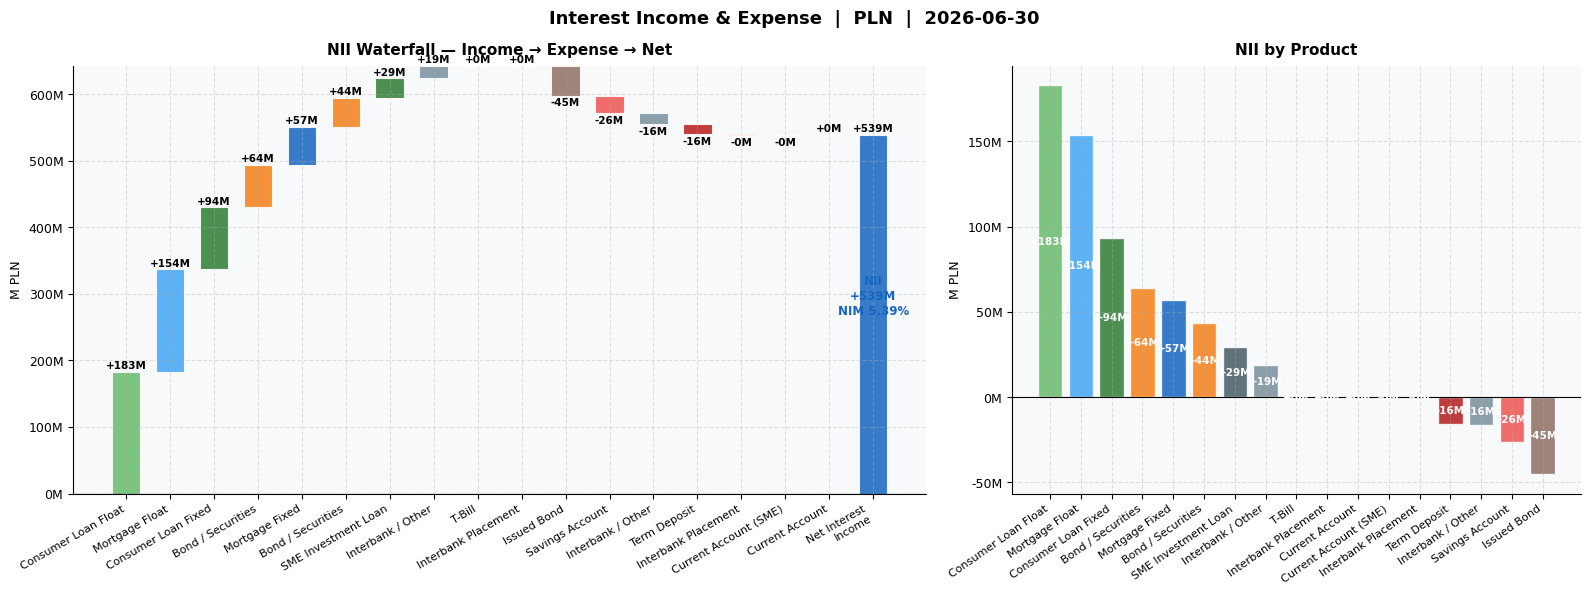

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={'width_ratios': [1.5, 1]})
fig.suptitle(f'Interest Income & Expense  |  {CCY}  |  {REPORT_DATE.date()}',
             fontsize=13, fontweight='bold')

# ── Waterfall ─────────────────────────────────────────────────────────────────
wf_labels, wf_vals, wf_bots, wf_cols = [], [], [], []
running = 0.0
for _, row in assets_p.sort_values('nii_interest', ascending=False).iterrows():
    wf_labels.append(row['label']); wf_vals.append(row['nii_interest']/1e6)
    wf_bots.append(running/1e6);    wf_cols.append(PRODUCT_COLORS.get(row['label'], C_INC))
    running += row['nii_interest']
for _, row in liabs_p.sort_values('nii_interest').iterrows():
    wf_labels.append(row['label']); wf_vals.append(row['nii_interest']/1e6)
    wf_bots.append(running/1e6);    wf_cols.append(PRODUCT_COLORS.get(row['label'], C_EXP))
    running += row['nii_interest']
wf_labels.append('Net Interest\nIncome'); wf_vals.append(nii_total/1e6)
wf_bots.append(0.0);                      wf_cols.append(C_NET)

x1 = np.arange(len(wf_labels))
bars1 = ax1.bar(x1, wf_vals, bottom=wf_bots, color=wf_cols,
                alpha=0.85, edgecolor='white', linewidth=0.8, width=0.65)
for bar, val in zip(bars1, wf_vals):
    ypos = bar.get_y() + bar.get_height() + (1.5 if val >= 0 else -3.5)
    ax1.text(bar.get_x() + bar.get_width()/2, ypos, f'{val:+.0f}M',
             ha='center', va='bottom' if val >= 0 else 'top',
             fontsize=7.5, fontweight='bold')
ax1.set_xticks(x1); ax1.set_xticklabels(wf_labels, rotation=30, ha='right', fontsize=8)
ax1.axhline(0, color='black', lw=0.8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax1.set_ylabel('M PLN'); ax1.set_title('NII Waterfall — Income → Expense → Net')
ax1.text(len(x1)-1, nii_total/1e6*0.5,
         f'NII\n{nii_total/1e6:+.0f}M\nNIM {nim_pct:.2f}%',
         ha='center', fontsize=8.5, color=C_NET, fontweight='bold')

# ── Per-product bar ───────────────────────────────────────────────────────────
_all = pd.concat([assets_p, liabs_p]).sort_values('nii_interest', ascending=False)
x2 = np.arange(len(_all))
cols2 = [PRODUCT_COLORS.get(r['label'], C_GR) for _, r in _all.iterrows()]
b2 = ax2.bar(x2, _all['nii_interest']/1e6, color=cols2, alpha=0.85, edgecolor='white')
for bar, (_, row) in zip(b2, _all.iterrows()):
    v = row['nii_interest']/1e6
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height()/2 + bar.get_y(),
             f'{v:+.0f}M', ha='center', va='center',
             fontsize=7.5, color='white', fontweight='bold')
ax2.set_xticks(x2); ax2.set_xticklabels(_all['label'], rotation=35, ha='right', fontsize=8)
ax2.axhline(0, color='black', lw=0.8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax2.set_title('NII by Product'); ax2.set_ylabel('M PLN')
plt.tight_layout(); plt.show()


---
## 2. Product Margin Analysis

Effective rate on each product vs blended cost of funds (assets) or blended asset yield (liabilities).
**Spread** = how much each product contributes above/below the bank's blended benchmark.


Product,S,Type,Bal(M),NII Int(M),Rate%,Bench%,Spread bps
Consumer Loan Float,A,Variable,"1,500",+183.0,12.20,1.18,+1102
Mortgage Float,A,Variable,"2,800",+154.0,5.50,1.18,+432
Consumer Loan Fixed,A,Fixed,900,+93.6,10.40,1.18,+922
Bond / Securities,A,Fixed,"1,400",+63.7,4.55,1.18,+337
Mortgage Fixed,A,Fixed,"1,000",+56.9,5.69,1.18,+451
Bond / Securities,A,Variable,"1,200",+43.6,3.63,1.18,+245
SME Investment Loan,A,Variable,600,+29.2,4.86,1.18,+368
Interbank / Other,A,Fixed,0,+18.9,0.00,1.18,-118
T-Bill,A,Fixed,200,+0.2,0.09,1.18,-109
Interbank Placement,A,Variable,200,+0.1,0.04,1.18,-115


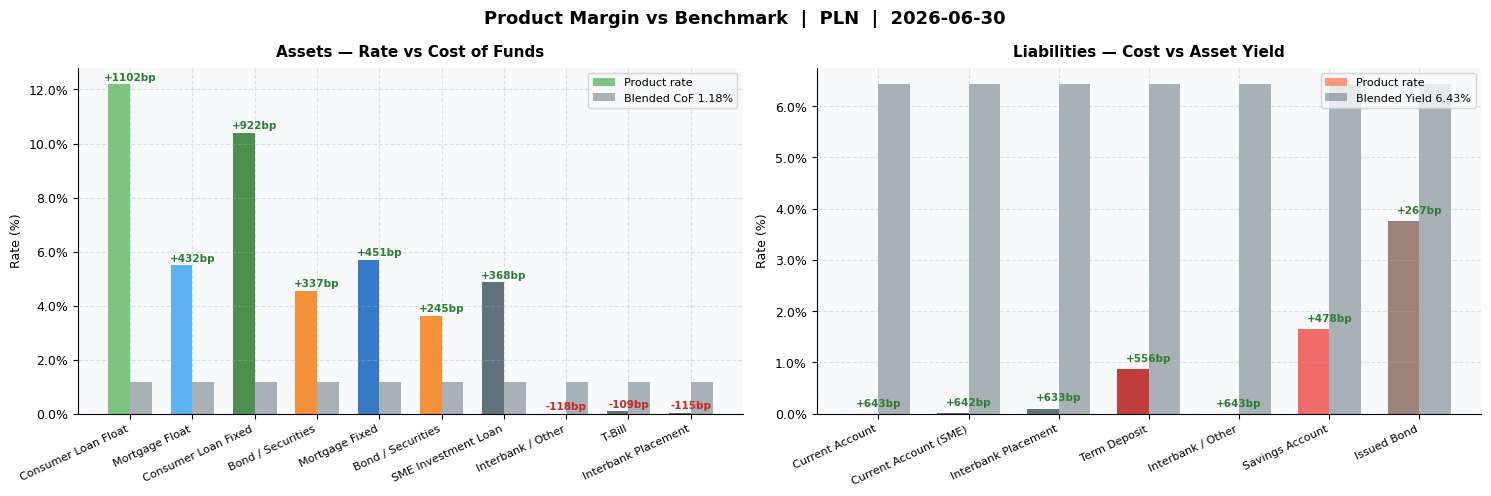

In [5]:
blended_cof = avg_cost_funds / 100
blended_yld = avg_asset_yld  / 100

rows = []
for _, r in prod.sort_values(['bs_side','nii_interest'], ascending=[True,False]).iterrows():
    bal   = r['balance_amt']
    nii_i = r['nii_interest']
    eff   = abs(nii_i) / bal if bal > 0 else 0.0
    spread = (eff - blended_cof) if r['bs_side']=='A' else (blended_yld - eff)
    rows.append({
        'Product':        r['label'],
        'Side':           r['bs_side'],
        'Type':           {'F':'Fixed','V':'Variable','A':'Admin'}.get(r['rate_type'], r['rate_type']),
        'Balance (M)':    round(bal/1e6, 0),
        'NII Int (M)':    round(nii_i/1e6, 1),
        'Eff. Rate (%)':  round(eff*100, 2),
        'Benchmark (%)':  round((blended_cof if r['bs_side']=='A' else blended_yld)*100, 2),
        'Spread (bps)':   round(spread*10000, 0),
    })
tbl = pd.DataFrame(rows)

_margin_rows = [
    [r['Product'], r['Side'], r['Type'], f"{r['Balance (M)']:,.0f}",
     f"{r['NII Int (M)']:+.1f}", f"{r['Eff. Rate (%)']:.2f}", f"{r['Benchmark (%)']:.2f}",
     pos_neg(r['Spread (bps)'], '+.0f')]
    for _, r in tbl.iterrows()
]
display(html_table(
    ['Product', 'S', 'Type', 'Bal(M)', 'NII Int(M)', 'Rate%', 'Bench%', 'Spread bps'],
    _margin_rows,
    aligns=['left','center','right','right','right','right','right','right'],
    title='Product Margin vs Benchmark',
    note=(f'Benchmark: Assets vs CoF {avg_cost_funds:.2f}%  |  Liabilities vs Yield '
          f'{avg_asset_yld:.2f}%.  Red spread = product priced below its benchmark.'),
))

# Chart
fig2, (axA, axL) = plt.subplots(1, 2, figsize=(15, 5))
fig2.suptitle(f'Product Margin vs Benchmark  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')
for ax, side, bench_val, bench_lbl, title in [
    (axA, 'A', avg_cost_funds, f'Blended CoF {avg_cost_funds:.2f}%', 'Assets — Rate vs Cost of Funds'),
    (axL, 'L', avg_asset_yld,  f'Blended Yield {avg_asset_yld:.2f}%', 'Liabilities — Cost vs Asset Yield'),
]:
    _s = tbl[tbl['Side']==side].reset_index(drop=True)
    if _s.empty: continue
    _x = np.arange(len(_s)); w = 0.35
    ax.bar(_x - w/2, _s['Eff. Rate (%)'],  w, label='Product rate',
           color=[PRODUCT_COLORS.get(lb, C_GR) for lb in _s['Product']], alpha=0.85)
    ax.bar(_x + w/2, [bench_val]*len(_s), w, label=bench_lbl,
           color=C_GR, alpha=0.45)
    for i, (_, row) in enumerate(_s.iterrows()):
        spd = row['Spread (bps)']
        col = C_INC if spd >= 0 else C_EXP
        ax.text(i, row['Eff. Rate (%)']+0.15, f'{spd:+.0f}bp',
                ha='center', fontsize=7.5, fontweight='bold', color=col)
    ax.set_xticks(_x); ax.set_xticklabels(_s['Product'], rotation=25, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
    ax.set_title(title); ax.set_ylabel('Rate (%)'); ax.legend()
plt.tight_layout(); plt.show()


---
## 3. Funding Cost Structure

Liability mix by balance and annual interest cost, with blended cost of funds benchmark.


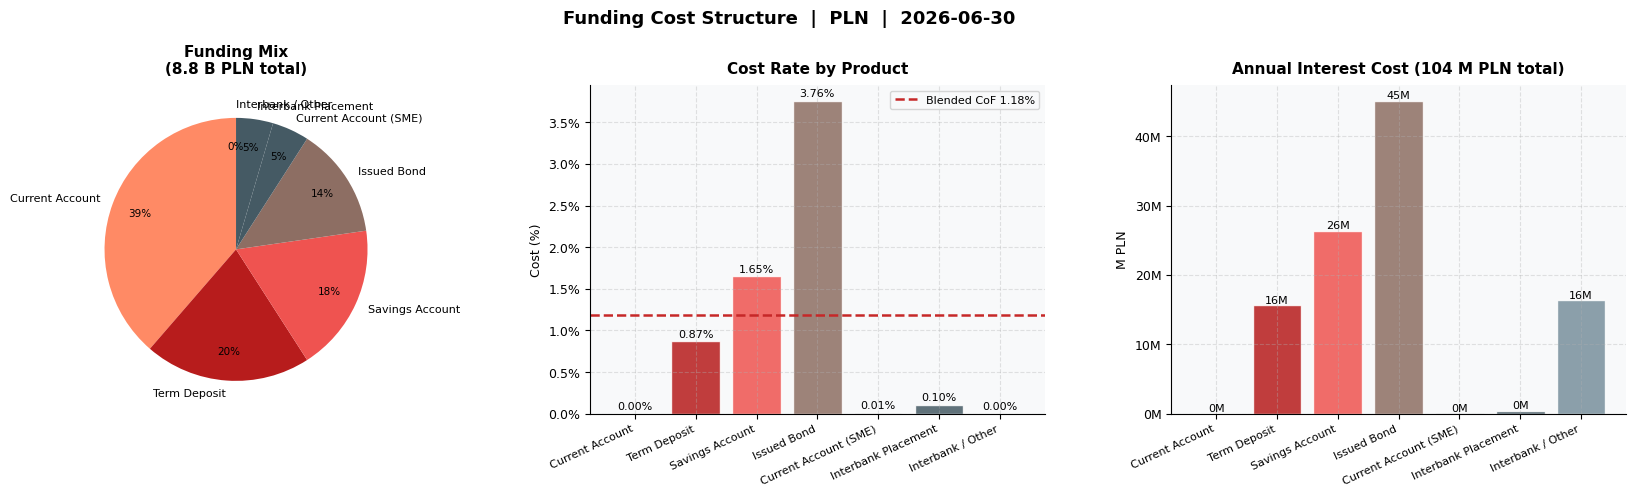

Product,Balance (M),Cost (M),Rate%,% of liabs
Current Account,"3,400",0.0,0.00,38.6%
Term Deposit,"1,800",15.6,0.87,20.5%
Savings Account,"1,600",26.4,1.65,18.2%
Issued Bond,"1,200",45.1,3.76,13.6%
Current Account (SME),400,0.0,0.01,4.5%
Interbank Placement,400,0.4,0.10,4.5%
Interbank / Other,0,16.3,nan,0.0%
TOTAL,"8,800",103.9,1.18,100.0%


In [6]:
_l = liabs_p.copy()
_l['bal_abs']  = _l['balance_amt'].abs()
_l['cost_abs'] = _l['nii_interest'].abs()
_l['eff_cost'] = _l['cost_abs'] / _l['bal_abs'].replace(0, np.nan)
_l = _l.sort_values('bal_abs', ascending=False)

fig3, axes3 = plt.subplots(1, 3, figsize=(17, 5))
fig3.suptitle(f'Funding Cost Structure  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

# Pie: funding mix
_cols_pie = [PRODUCT_COLORS.get(lb, C_GR) for lb in _l['label']]
wedges, texts, autos = axes3[0].pie(
    _l['bal_abs'], labels=_l['label'], autopct='%1.0f%%',
    colors=_cols_pie, startangle=90, pctdistance=0.78,
    textprops={'fontsize': 8})
for a in autos: a.set_fontsize(7.5)
axes3[0].set_title(f'Funding Mix\n({total_liabs/1e9:.1f} B PLN total)')

# Bar: cost rate
_x = np.arange(len(_l))
_rt = (_l['eff_cost'].fillna(0) * 100).tolist()
b_r = axes3[1].bar(_x, _rt, color=_cols_pie, alpha=0.85, edgecolor='white')
for bar, v in zip(b_r, _rt):
    axes3[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                  f'{v:.2f}%', ha='center', fontsize=8)
axes3[1].axhline(avg_cost_funds, color=C_EXP, lw=1.8, ls='--',
                 label=f'Blended CoF {avg_cost_funds:.2f}%')
axes3[1].set_xticks(_x); axes3[1].set_xticklabels(_l['label'], rotation=25, ha='right', fontsize=8)
axes3[1].yaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
axes3[1].set_title('Cost Rate by Product'); axes3[1].set_ylabel('Cost (%)'); axes3[1].legend()

# Bar: annual cost M PLN
_cm = (_l['cost_abs']/1e6).tolist()
b_c = axes3[2].bar(_x, _cm, color=_cols_pie, alpha=0.85, edgecolor='white')
for bar, v in zip(b_c, _cm):
    axes3[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                  f'{v:.0f}M', ha='center', fontsize=8)
axes3[2].set_xticks(_x); axes3[2].set_xticklabels(_l['label'], rotation=25, ha='right', fontsize=8)
axes3[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
axes3[2].set_title(f'Annual Interest Cost ({total_exp/1e6:.0f} M PLN total)')
axes3[2].set_ylabel('M PLN')
plt.tight_layout(); plt.show()

_fund_rows = [
    [r['label'], f'{r["bal_abs"]/1e6:,.0f}', f'{r["cost_abs"]/1e6:.1f}',
     f'{(r["eff_cost"] or 0)*100:.2f}', f'{r["bal_abs"]/total_liabs*100:.1f}%']
    for _, r in _l.iterrows()
]
display(html_table(
    ['Product', 'Balance (M)', 'Cost (M)', 'Rate%', '% of liabs'],
    _fund_rows,
    total_row=['TOTAL', f'{total_liabs/1e6:,.0f}', f'{total_exp/1e6:.1f}',
               f'{avg_cost_funds:.2f}', '100.0%'],
))


---
## 4. Fixed vs Variable Rate Exposure

How much of the balance sheet reprices when market rates move.
`Fixed` — contractually locked. `Variable` — resets to WIBOR + spread. `Admin` — floored at 0% (e.g. current accounts).


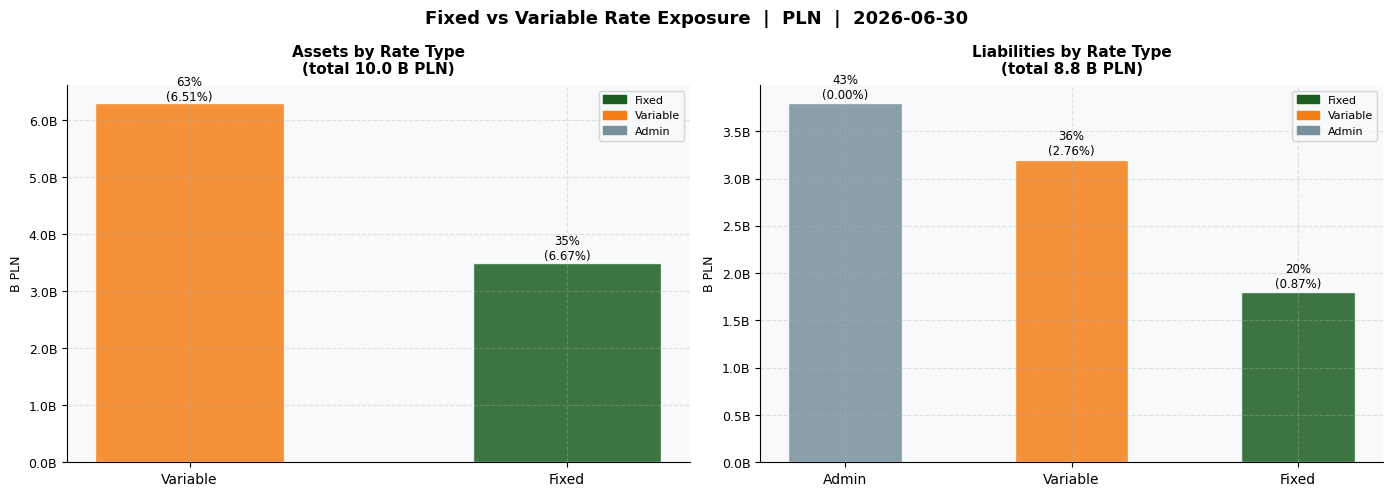

Assets,Balance,% of total,Avg rate
Fixed,3.50 B PLN,35.7%,6.67%
Variable,6.30 B PLN,64.3%,6.51%


Liabilities,Balance,% of total,Avg rate
Fixed,1.80 B PLN,20.5%,0.87%
Variable,3.20 B PLN,36.4%,2.76%
Admin,3.80 B PLN,43.2%,0.00%


In [7]:
fig4, (ax4a, ax4l) = plt.subplots(1, 2, figsize=(14, 5))
fig4.suptitle(f'Fixed vs Variable Rate Exposure  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

RT_COLORS = {'Fixed': C_FIX, 'Variable': C_VAR, 'Admin': C_ADM}
RT_MAP    = {'F': 'Fixed', 'V': 'Variable', 'A': 'Admin'}

for ax, side, total_b, title in [
    (ax4a, 'A', total_assets, 'Assets by Rate Type'),
    (ax4l, 'L', total_liabs,  'Liabilities by Rate Type'),
]:
    _s  = prod[prod['bs_side']==side].copy()
    _grp = (_s.groupby('rate_type')
              .agg(balance=('balance_amt','sum'), nii_int=('nii_interest','sum'))
              .reset_index())
    _grp['label']    = _grp['rate_type'].map(RT_MAP)
    _grp['eff_rate'] = _grp['nii_int'].abs() / _grp['balance'].replace(0, np.nan)
    _grp = _grp.sort_values('balance', ascending=False)

    _x = np.arange(len(_grp))
    _bc = [RT_COLORS.get(lb, C_GR) for lb in _grp['label']]
    bars4 = ax.bar(_x, _grp['balance']/1e9, color=_bc, alpha=0.85,
                   edgecolor='white', width=0.5)
    for bar, (_, row) in zip(bars4, _grp.iterrows()):
        pct = row['balance'] / total_b * 100
        rate_s = f"{row['eff_rate']*100:.2f}%" if pd.notna(row['eff_rate']) else 'n/a'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{pct:.0f}%\n({rate_s})', ha='center', fontsize=8.5)
    ax.set_xticks(_x); ax.set_xticklabels(_grp['label'], fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.1f}B'))
    ax.set_title(f'{title}\n(total {total_b/1e9:.1f} B PLN)')
    ax.set_ylabel('B PLN')
    ax.legend(handles=[mpatches.Patch(color=c,label=l) for l,c in RT_COLORS.items()])

plt.tight_layout(); plt.show()

for side, lbl in [('A','Assets'),('L','Liabilities')]:
    _s = prod[prod['bs_side']==side]; tot = _s['balance_amt'].abs().sum()
    _rt_rows = []
    for rt, rl in [('F','Fixed'),('V','Variable'),('A','Admin')]:
        _r = _s[_s['rate_type']==rt]
        if _r.empty: continue
        b = _r['balance_amt'].abs().sum()
        eff = abs(_r['nii_interest'].sum()) / b * 100 if b else 0
        _rt_rows.append([rl, f'{b/1e9:.2f} B PLN', f'{b/tot*100:.1f}%', f'{eff:.2f}%'])
    display(html_table(
        [lbl, 'Balance', '% of total', 'Avg rate'],
        _rt_rows,
        aligns=['left','right','right','right'],
    ))


---
## 5. NII Bridge — Locked Interest vs Renewal

**Locked interest** (`nii_interest`): income from CFs already on the book — rate and amount are contractually fixed regardless of market moves.
**Renewal** (`nii_renewal`): income from maturing capital reinvested at current market rates within the 1-year horizon.

Locked NII is immune to rate shocks; renewal NII reprices at market.


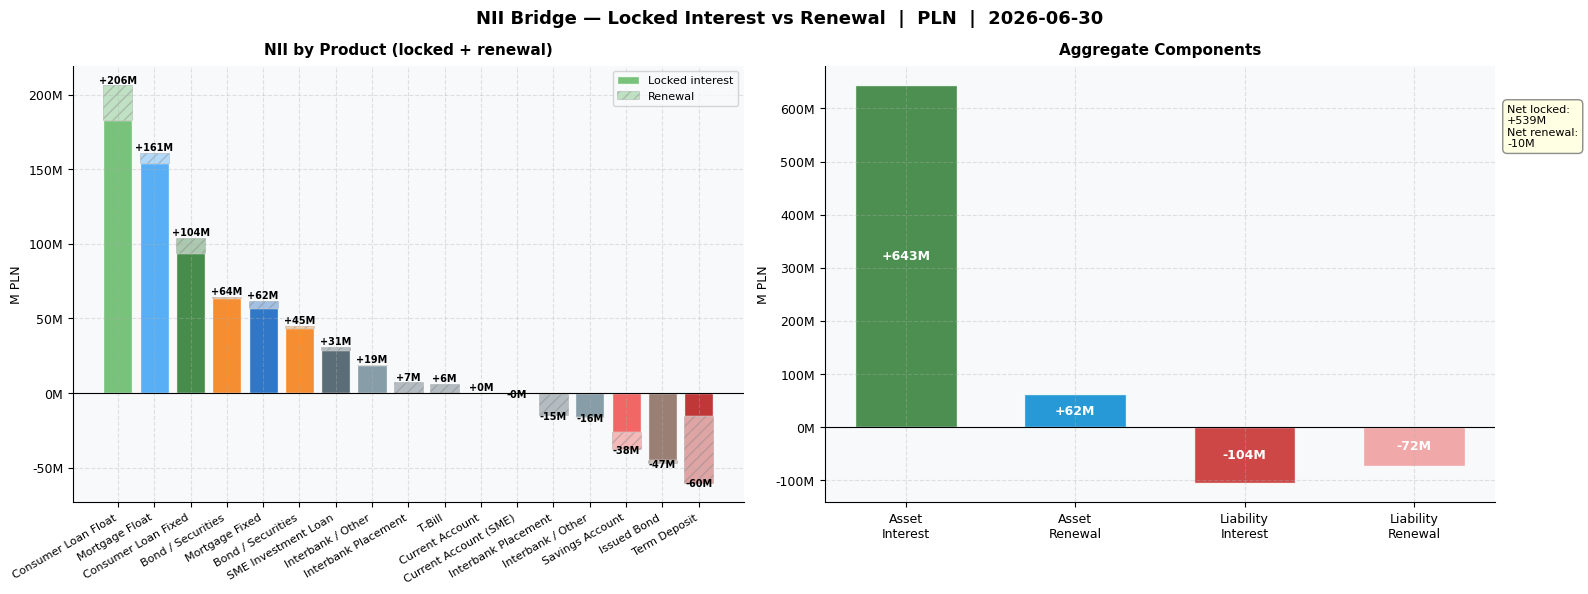

Product (Side),Interest (M),Renewal (M),Total (M)
Consumer Loan Float (A),+183.0,+23.1,+206.1
Mortgage Float (A),+154.0,+7.1,+161.1
Consumer Loan Fixed (A),+93.6,+10.3,+103.9
Bond / Securities (A),+63.7,+0.6,+64.4
Mortgage Fixed (A),+56.9,+4.7,+61.6
Bond / Securities (A),+43.6,+1.3,+44.9
SME Investment Loan (A),+29.2,+1.7,+30.9
Interbank / Other (A),+18.9,+0.0,+18.9
Interbank Placement (A),+0.1,+7.1,+7.1
T-Bill (A),+0.2,+5.8,+6.0


In [8]:
_bridge = prod.sort_values(['bs_side','nii_total'], ascending=[True,False]).copy()
_bridge['int_m'] = _bridge['nii_interest']/1e6
_bridge['ren_m'] = _bridge['nii_renewal']/1e6
_bridge['tot_m'] = _bridge['nii_total']/1e6

fig5, (ax5a, ax5b) = plt.subplots(1, 2, figsize=(16, 6))
fig5.suptitle(f'NII Bridge — Locked Interest vs Renewal  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

_x5 = np.arange(len(_bridge))
_c5 = [PRODUCT_COLORS.get(lb, C_GR) for lb in _bridge['label']]

ax5a.bar(_x5, _bridge['int_m'], color=_c5, alpha=0.88, label='Locked interest', edgecolor='white')
ax5a.bar(_x5, _bridge['ren_m'], bottom=_bridge['int_m'], color=_c5,
         alpha=0.38, hatch='///', edgecolor='grey', linewidth=0.5, label='Renewal')
for i, (_, row) in enumerate(_bridge.iterrows()):
    t = row['tot_m']
    ax5a.text(i, t + (1.5 if t >= 0 else -3), f'{t:+.0f}M',
              ha='center', fontsize=7, fontweight='bold')
ax5a.set_xticks(_x5); ax5a.set_xticklabels(_bridge['label'], rotation=30, ha='right', fontsize=8)
ax5a.axhline(0, color='black', lw=0.8)
ax5a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax5a.set_title('NII by Product (locked + renewal)'); ax5a.set_ylabel('M PLN'); ax5a.legend()

# Aggregate summary bar (right)
_agg_vals = [
    float(assets_p['nii_interest'].sum())/1e6,
    float(assets_p['nii_renewal'].sum())/1e6,
    float(liabs_p['nii_interest'].sum())/1e6,
    float(liabs_p['nii_renewal'].sum())/1e6,
]
_agg_lbls = ['Asset\nInterest','Asset\nRenewal','Liability\nInterest','Liability\nRenewal']
_agg_cols = [C_INC, C_REN, C_EXP, '#EF9A9A']
b5b = ax5b.bar(range(4), _agg_vals, color=_agg_cols, alpha=0.85, edgecolor='white', width=0.6)
for bar, v in zip(b5b, _agg_vals):
    ax5b.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2+bar.get_y(),
              f'{v:+.0f}M', ha='center', va='center', fontsize=9,
              fontweight='bold', color='white')
ax5b.set_xticks(range(4)); ax5b.set_xticklabels(_agg_lbls, fontsize=9)
ax5b.axhline(0, color='black', lw=0.8)
ax5b.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax5b.set_title('Aggregate Components'); ax5b.set_ylabel('M PLN')
_tot_int = sum(_agg_vals[0::2]); _tot_ren = sum(_agg_vals[1::2])
ax5b.text(3.55, max(_agg_vals)*0.82,
          f'Net locked:\n{_tot_int:+.0f}M\nNet renewal:\n{_tot_ren:+.0f}M',
          fontsize=8, ha='left',
          bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='grey', alpha=0.9))
plt.tight_layout(); plt.show()

_bridge_rows = [
    [f'{r["label"]} ({r["bs_side"]})', pos_neg(r['int_m'], '+.1f'),
     pos_neg(r['ren_m'], '+.1f'), pos_neg(r['tot_m'], '+.1f')]
    for _, r in _bridge.iterrows()
]
display(html_table(
    ['Product (Side)', 'Interest (M)', 'Renewal (M)', 'Total (M)'],
    _bridge_rows,
    total_row=['NET', pos_neg(_tot_int, '+.1f'), pos_neg(_tot_ren, '+.1f'),
               pos_neg(_tot_int + _tot_ren, '+.1f')],
))


---
## 6. Product Interest Margin — Client Rate vs Market Rate

**Margin** = client rate − market rate (forward/swap curve rate for that tenor).
- Assets: positive margin = bank earns above market → pricing power / franchise value.
- Liabilities: negative margin = bank pays below market → funding advantage (e.g. current accounts at 0% vs WIBOR).

The **contribution** column converts margin into annual PLN value: balance × margin (annualised).


Product,S,Type,Bal(M),Client rt%,Market rt%,Margin bps,Contribution M
Consumer Loan Float,A,Variable,"1,500",13.90,3.91,+999,+149.9
Consumer Loan Fixed,A,Fixed,900,11.35,4.35,+700,+63.0
Mortgage Float,A,Variable,"2,800",5.93,3.89,+204,+57.1
Mortgage Fixed,A,Fixed,"1,000",6.59,4.60,+199,+19.9
SME Investment Loan,A,Variable,600,5.33,3.89,+144,+8.6
Interbank Placement,A,Variable,200,3.78,3.56,+22,+0.4
Interbank / Other,A,Fixed,0,4.50,4.50,+0,+0.0
Bond / Securities,A,Fixed,"1,400",4.87,4.87,+0,+0.0
Bond / Securities,A,Variable,"1,200",3.90,3.90,+0,+0.0
T-Bill,A,Fixed,200,3.74,3.74,-0,-0.0


Margin Value / Year,M PLN
Assets total contribution,+298.9
Liabilities total contribution,-160.7
Combined margin value,+138.2


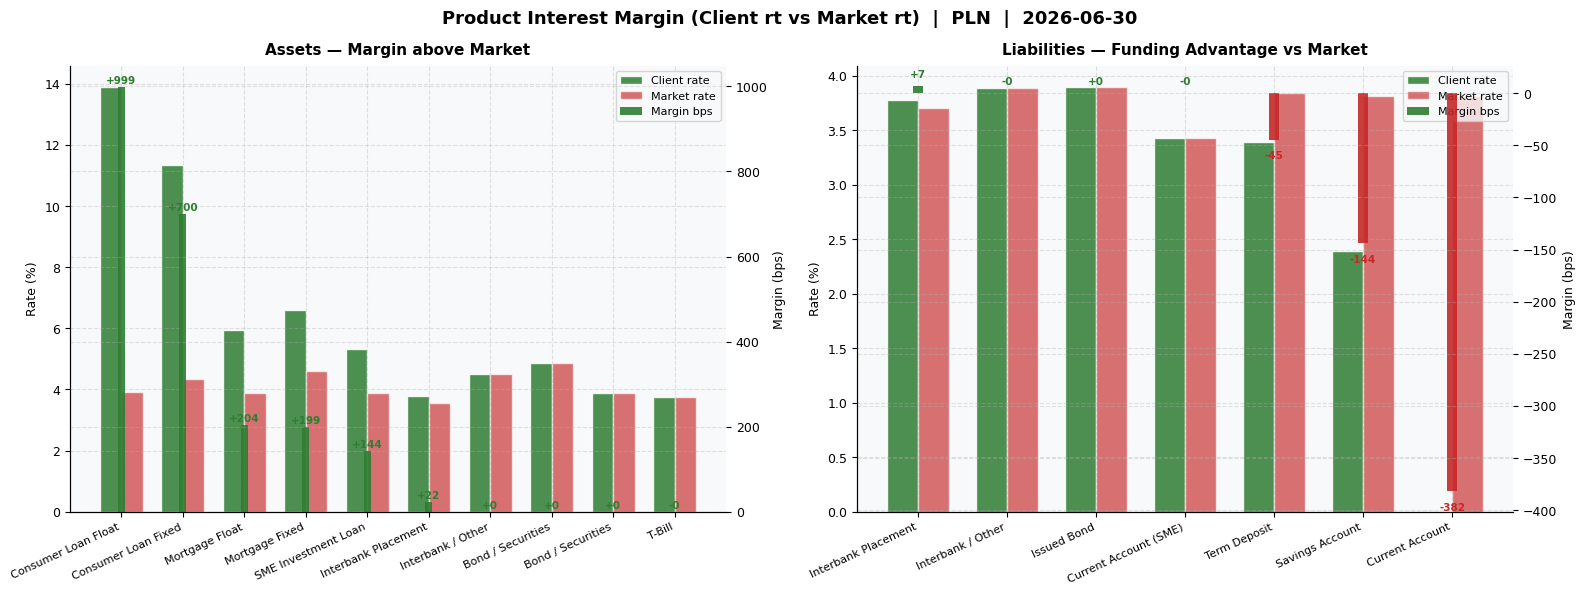

In [9]:
_nii_d = pd.read_sql(
    "SELECT product_code, bs_side, rate_type, tenor_bucket, beh_outstanding, client_rt, fwd_rt, margin "
    "FROM cf.nii_base_scenario WHERE scenario_id='base'",
    ENGINE)

def _wavg(df, val_col, wgt_col):
    w = df[wgt_col].abs()
    return (df[val_col] * w).sum() / w.sum() if w.sum() else 0.0

_bal_lkp = (prod.set_index(['product_code','bs_side'])['balance_amt'].abs().to_dict())

_pm_rows = []
for (pc, side, rt), g in _nii_d.groupby(['product_code','bs_side','rate_type']):
    bal = _bal_lkp.get((pc, side), 0.0)
    c_rt  = _wavg(g, 'client_rt', 'beh_outstanding') * 100
    m_rt  = _wavg(g, 'fwd_rt',    'beh_outstanding') * 100
    marg  = c_rt - m_rt
    contrib = bal * marg / 100 / 1e6   # M PLN annual
    lbl = PROD_LABELS.get(pc, pc)
    _pm_rows.append({'Product': lbl, 'Side': side, 'Type': {'F':'Fixed','V':'Variable','A':'Admin'}.get(rt,rt),
                     'Balance (M)': round(bal/1e6,0), 'Client rt (%)': round(c_rt,2),
                     'Market rt (%)': round(m_rt,2), 'Margin (bps)': round(marg*100,0),
                     'Contribution (M)': round(contrib,1), '_order': 0 if side=='A' else 1})
_pm = pd.DataFrame(_pm_rows).sort_values(['_order','Margin (bps)'], ascending=[True,False]).drop(columns='_order')

# ── Table ──────────────────────────────────────────────────────────────────
def _pm_flag_color(r):
    weak = (r['Side']=='A' and r['Margin (bps)'] < 0) or (r['Side']=='L' and r['Margin (bps)'] > 0)
    return '#C62828' if weak else None

_pm_rows = []
for _, r in _pm.iterrows():
    color = _pm_flag_color(r)
    _pm_rows.append([
        r['Product'], r['Side'], r['Type'], f"{r['Balance (M)']:,.0f}",
        f"{r['Client rt (%)']:.2f}", f"{r['Market rt (%)']:.2f}",
        (f"{r['Margin (bps)']:+.0f}", color),
        (f"{r['Contribution (M)']:+.1f}", color),
    ])
display(html_table(
    ['Product', 'S', 'Type', 'Bal(M)', 'Client rt%', 'Market rt%', 'Margin bps', 'Contribution M'],
    _pm_rows,
    aligns=['left','center','right','right','right','right','right','right'],
    note='Red = asset priced below market or liability priced above market (margin working against the bank).',
))
_tot_a = _pm[_pm['Side']=='A']['Contribution (M)'].sum()
_tot_l = _pm[_pm['Side']=='L']['Contribution (M)'].sum()
display(html_table(
    ['Margin Value / Year', 'M PLN'],
    [
        ['Assets total contribution',      pos_neg(_tot_a, '+.1f')],
        ['Liabilities total contribution', pos_neg(_tot_l, '+.1f')],
    ],
    total_row=['Combined margin value', pos_neg(_tot_a + _tot_l, '+.1f')],
))

# ── Chart ─────────────────────────────────────────────────────────────────
fig6, (ax6a, ax6b) = plt.subplots(1, 2, figsize=(16, 6))
fig6.suptitle(f'Product Interest Margin (Client rt vs Market rt)  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

for ax, side, title in [(ax6a,'A','Assets — Margin above Market'),
                         (ax6b,'L','Liabilities — Funding Advantage vs Market')]:
    _s = _pm[_pm['Side']==side].copy()
    _x = np.arange(len(_s))
    w  = 0.35
    b_c = ax.bar(_x - w/2, _s['Client rt (%)'],  w, color=C_INC, alpha=0.85, label='Client rate', edgecolor='white')
    b_m = ax.bar(_x + w/2, _s['Market rt (%)'],  w, color=C_EXP, alpha=0.65, label='Market rate', edgecolor='white')
    ax2 = ax.twinx()
    marg_vals = _s['Margin (bps)'].tolist()
    mc = [C_INC if v >= 0 else C_EXP for v in marg_vals]
    ax2.bar(_x, marg_vals, 0.12, color=mc, alpha=0.9, label='Margin bps')
    for i, v in enumerate(marg_vals):
        ax2.text(i, v + (8 if v >= 0 else -18), f'{v:+.0f}',
                 ha='center', fontsize=7.5, fontweight='bold',
                 color=C_INC if v >= 0 else C_EXP)
    ax.set_xticks(_x); ax.set_xticklabels(_s['Product'], rotation=25, ha='right', fontsize=8)
    ax.set_ylabel('Rate (%)'); ax2.set_ylabel('Margin (bps)')
    ax.set_title(title)
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper right')

plt.tight_layout(); plt.show()


---
## 7. Margin Profile over Time

How the **interest margin** (client rate − market rate) varies across tenor buckets —
i.e. which part of the book has the margin locked in, and which is rolling off soon.

- **High margin in short buckets**: maturing positions repricing soon, margin at risk.
- **High margin in long buckets**: margin locked in for years ahead.
- **NIM per bucket** = weighted asset client rt − weighted liability client rt within that tenor horizon.


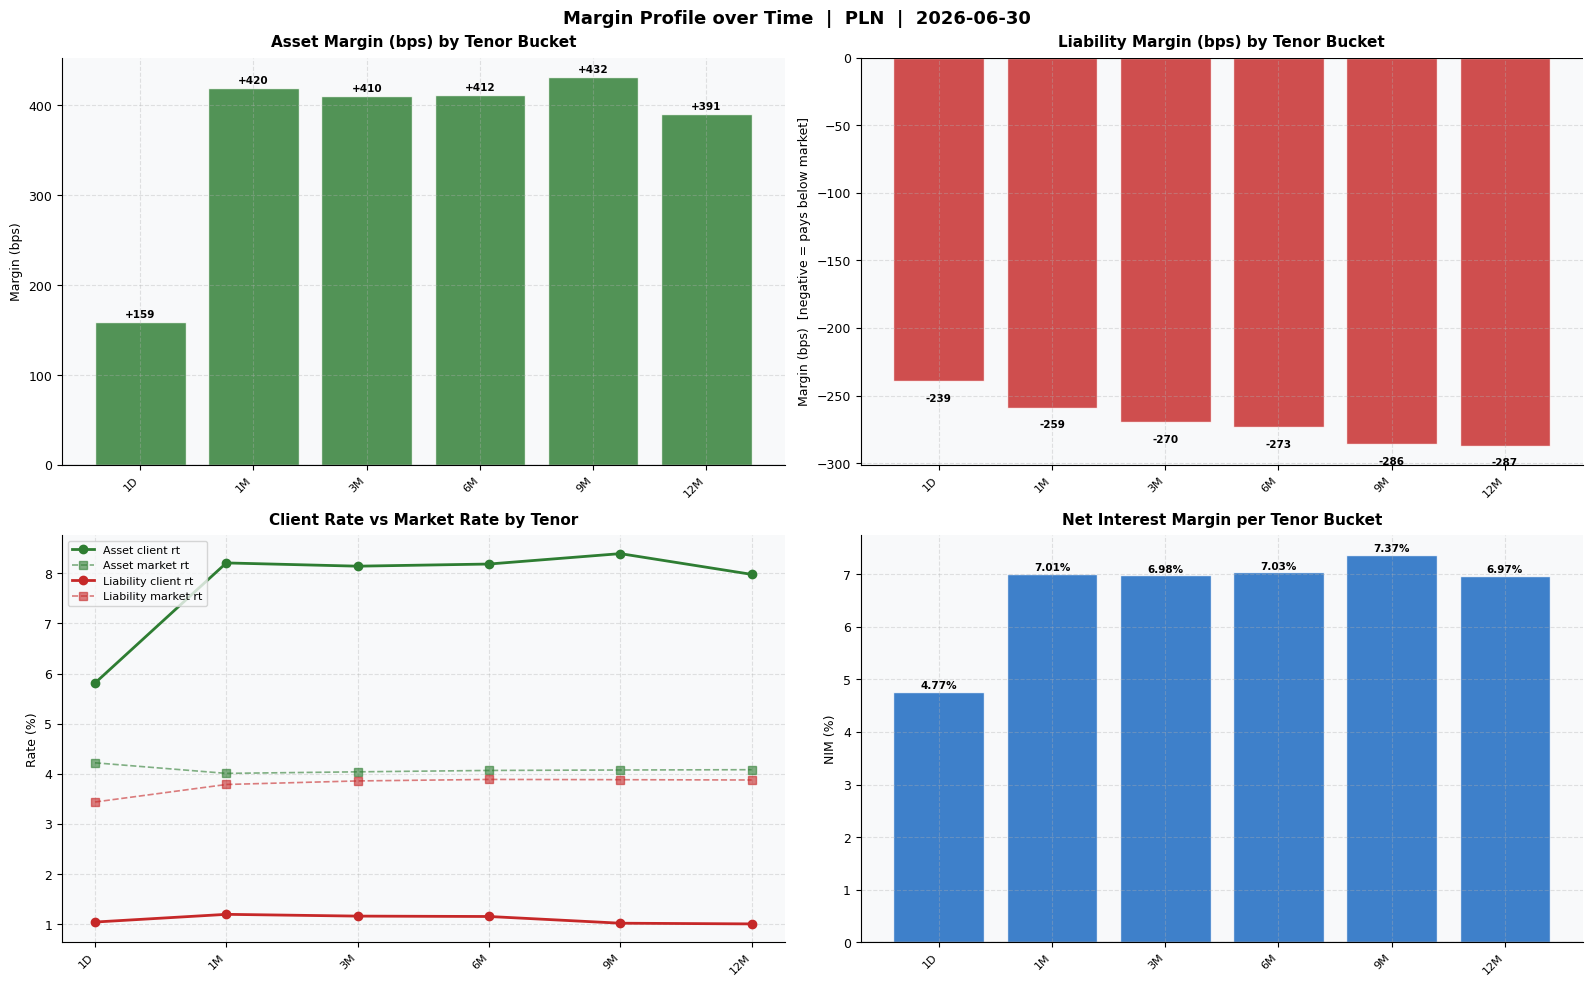

Bucket,Asset marg (bps),Liab marg (bps),NIM,Asset bal (M),Liab bal (M)
1D,+159,-239,4.77%,437,"5,560"
1M,+420,-259,7.01%,"6,762","4,712"
3M,+410,-270,6.98%,"11,779","4,583"
6M,+412,-273,7.03%,"20,111","12,835"
9M,+432,-286,7.37%,"20,127","14,867"
12M,+391,-287,6.97%,"18,943","10,439"


In [10]:
_mt = pd.read_sql(
    "SELECT bs_side, tenor_bucket, beh_outstanding, client_rt, fwd_rt, margin "
    "FROM cf.nii_base_scenario WHERE scenario_id='base'",
    ENGINE)

def _wavg(df, val_col, wgt_col):
    w = df[wgt_col].abs()
    return (df[val_col] * w).sum() / w.sum() if w.sum() else 0.0

_bkt_rows = []
for (side, bkt), g in _mt.groupby(['bs_side','tenor_bucket']):
    _bkt_rows.append({
        'bs_side': side, 'tenor_bucket': bkt,
        'bal_m':      g['beh_outstanding'].abs().sum() / 1e6,
        'client_rt':  _wavg(g, 'client_rt', 'beh_outstanding') * 100,
        'fwd_rt':     _wavg(g, 'fwd_rt',    'beh_outstanding') * 100,
        'margin_bps': _wavg(g, 'margin',    'beh_outstanding') * 10000,
    })
_bkt = pd.DataFrame(_bkt_rows)
_bkt['_s'] = _bkt['tenor_bucket'].map(tkey)
_bkt = _bkt.sort_values(['bs_side','_s'])

_ba = _bkt[_bkt['bs_side']=='A'].reset_index(drop=True)
_bl = _bkt[_bkt['bs_side']=='L'].reset_index(drop=True)
_common_bkts = sorted(set(_ba['tenor_bucket']) & set(_bl['tenor_bucket']),
                      key=lambda b: tkey(b))
_ba_c = _ba[_ba['tenor_bucket'].isin(_common_bkts)].set_index('tenor_bucket').loc[_common_bkts]
_bl_c = _bl[_bl['tenor_bucket'].isin(_common_bkts)].set_index('tenor_bucket').loc[_common_bkts]
_nim_bkt = _ba_c['client_rt'] - _bl_c['client_rt']

fig7, axes7 = plt.subplots(2, 2, figsize=(16, 10))
fig7.suptitle(f'Margin Profile over Time  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

# Top-left: asset margin bps per bucket
ax = axes7[0,0]
_xa = np.arange(len(_ba))
_ca = [C_INC if v >= 0 else C_EXP for v in _ba['margin_bps']]
ax.bar(_xa, _ba['margin_bps'], color=_ca, alpha=0.82, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
for i, v in enumerate(_ba['margin_bps']):
    ax.text(i, v + (5 if v >= 0 else -15), f'{v:+.0f}', ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(_xa); ax.set_xticklabels(_ba['tenor_bucket'], rotation=45, ha='right', fontsize=8)
ax.set_title('Asset Margin (bps) by Tenor Bucket'); ax.set_ylabel('Margin (bps)')

# Top-right: liability margin bps per bucket
ax = axes7[0,1]
_xl = np.arange(len(_bl))
_cl = [C_INC if v >= 0 else C_EXP for v in _bl['margin_bps']]
ax.bar(_xl, _bl['margin_bps'], color=_cl, alpha=0.82, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
for i, v in enumerate(_bl['margin_bps']):
    ax.text(i, v + (5 if v >= 0 else -15), f'{v:+.0f}', ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(_xl); ax.set_xticklabels(_bl['tenor_bucket'], rotation=45, ha='right', fontsize=8)
ax.set_title('Liability Margin (bps) by Tenor Bucket'); ax.set_ylabel('Margin (bps)  [negative = pays below market]')

# Bottom-left: client_rt vs fwd_rt line chart, assets vs liabilities
ax = axes7[1,0]
_xc = np.arange(len(_common_bkts))
ax.plot(_xc, _ba_c['client_rt'].values, 'o-', color=C_INC, lw=2, label='Asset client rt')
ax.plot(_xc, _ba_c['fwd_rt'].values,    's--', color=C_INC, lw=1.2, alpha=0.6, label='Asset market rt')
ax.plot(_xc, _bl_c['client_rt'].values, 'o-', color=C_EXP, lw=2, label='Liability client rt')
ax.plot(_xc, _bl_c['fwd_rt'].values,    's--', color=C_EXP, lw=1.2, alpha=0.6, label='Liability market rt')
ax.set_xticks(_xc); ax.set_xticklabels(_common_bkts, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Rate (%)'); ax.set_title('Client Rate vs Market Rate by Tenor'); ax.legend(fontsize=8)

# Bottom-right: NIM per bucket (asset client_rt - liability client_rt)
ax = axes7[1,1]
_xn = np.arange(len(_nim_bkt))
_cn = [C_NET if v >= 0 else C_EXP for v in _nim_bkt]
ax.bar(_xn, _nim_bkt.values, color=_cn, alpha=0.82, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
for i, v in enumerate(_nim_bkt):
    ax.text(i, v + (0.05 if v >= 0 else -0.15), f'{v:.2f}%',
            ha='center', fontsize=7.5, fontweight='bold')
ax.set_xticks(_xn); ax.set_xticklabels(_common_bkts, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('NIM (%)'); ax.set_title('Net Interest Margin per Tenor Bucket')

plt.tight_layout(); plt.show()

# Text summary
_margtime_rows = []
for bkt in _common_bkts:
    ra = _ba_c.loc[bkt]; rl = _bl_c.loc[bkt]
    nim = ra['client_rt'] - rl['client_rt']
    _margtime_rows.append([
        bkt, pos_neg(ra['margin_bps'], '+.0f'), pos_neg(rl['margin_bps'], '+.0f'),
        f'{nim:.2f}%', f"{ra['bal_m']:,.0f}", f"{rl['bal_m']:,.0f}",
    ])
display(html_table(
    ['Bucket', 'Asset marg (bps)', 'Liab marg (bps)', 'NIM', 'Asset bal (M)', 'Liab bal (M)'],
    _margtime_rows,
    title='Margin profile — weighted avg by tenor bucket',
))


---
## 8. Economic Profit (EP) — Total & Per-Product

**EP = Margin (over FTP) + Fee − Expected Loss − Cost of Capital − OpEx**, the same objective
`bs_optimization/` uses to compare candidate balance sheets. Shown here for the book *as it stands
today* — not as an optimization — split by product so you can see which products are economically
strong vs. weak on a fully-loaded basis, not just on raw interest margin.

Sourced from `optimize_prep/output/product_params.npz` and `ftp_rates.npz` (the same per-product
economics `bs_optimization/` reads), not from SQL like the rest of this report — see the technical
notes for why that's a separate data source. Regenerate both via the `labbank_data_job`/
`optimize_prep_job` Dagster jobs (or `optimize_prep/python_code/opt_prep_workflow.py` +
`build_ftp_rates.py` directly) if you've changed the balance sheet and want fresh EP figures.

Acquisition cost is intentionally excluded — it's a cost of *growing* the balance sheet in the
optimizer, not a steady-state cost, so it's zero for the book as it stands.


Economic Profit (EP) Components,Value
Margin (over FTP),+487.6
Equity benefit,+17.4
Fee income,+7.6
Expected loss (EL),-45.0
Cost of capital (CoC),-43.4
Operating cost (OpEx),-127.7
ECONOMIC PROFIT (EP),+296.5


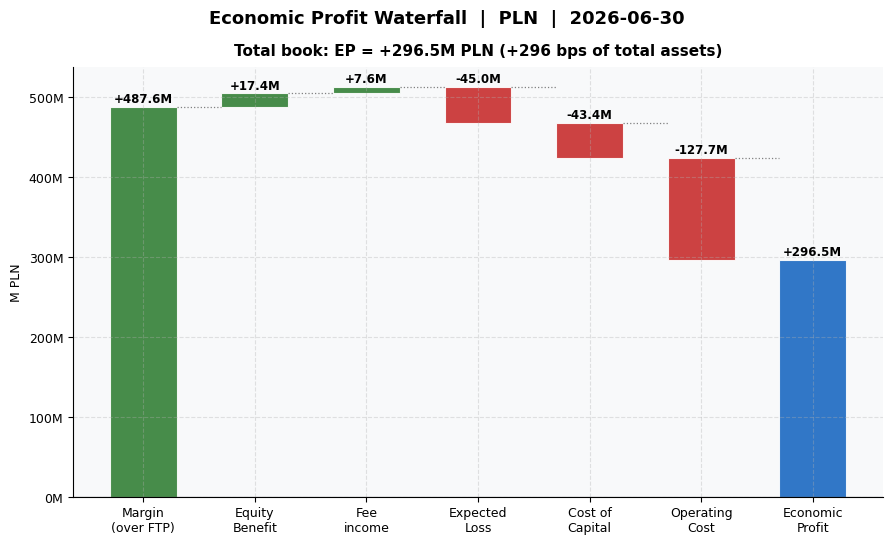

Product,Side,Bal(M),Margin(M),EqBen(M),Fee(M),EL(M),CoC(M),OpEx(M),EP(M),EP(bps)
Current Account,L,"3,400",+141.2,+0.0,+0.0,-0.0,-0.0,-22.1,+119.1,+350
Consumer Loan Float,A,"1,500",+147.3,+5.3,+3.0,-16.9,-13.5,-9.7,+115.5,+770
Consumer Loan Fixed,A,900,+63.7,+3.6,+1.8,-8.1,-8.1,-5.8,+47.1,+523
Mortgage Float,A,"2,800",+52.5,+4.6,+1.4,-8.4,-11.8,-18.2,+20.1,+72
Savings Account,L,"1,600",+28.8,+0.0,+0.0,-0.0,-0.0,-10.4,+18.4,+115
Interbank / Other,A,420,+18.9,+0.0,+0.0,-0.0,-0.0,-2.7,+16.2,+385
Current Account (SME),L,400,+16.6,+0.0,+0.0,-0.0,-0.0,-2.6,+14.0,+349
Mortgage Fixed,A,"1,000",+24.0,+1.6,+0.5,-2.0,-4.2,-6.5,+13.4,+134
5400,E,400,+0.0,+0.0,+0.0,-0.0,-0.0,-0.0,+0.0,+0
5300,E,400,+0.0,+0.0,+0.0,-0.0,-0.0,-0.0,+0.0,+0


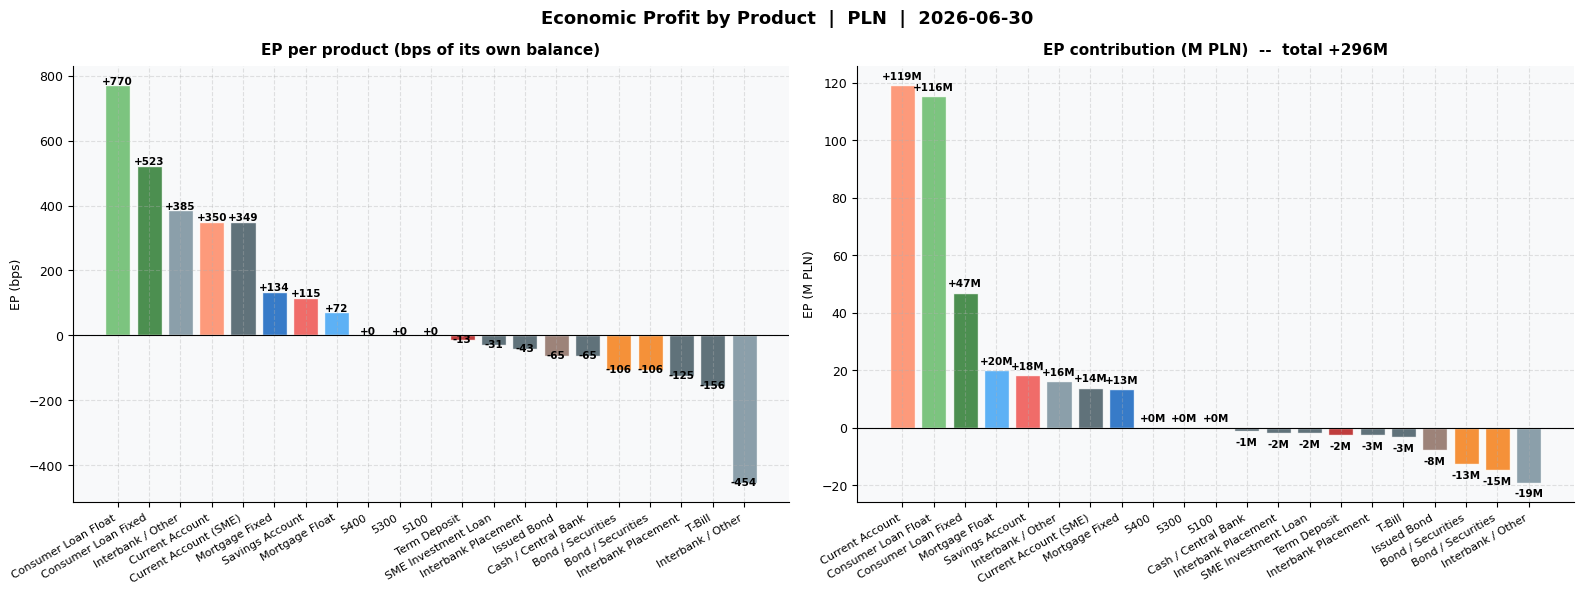

In [11]:
import sys, os

_OPT_PREP_DIR = os.path.normpath(os.path.join(os.getcwd(), '..', 'optimize_prep', 'python_code'))
if _OPT_PREP_DIR not in sys.path:
    sys.path.insert(0, _OPT_PREP_DIR)
from bs_vector import BalanceSheetParams
from ftp_store import load_ftp_rates, margin_unit_rate, equity_benefit_unit_rate

PARAMS_PATH = os.path.normpath(os.path.join(os.getcwd(), '..', 'optimize_prep', 'output', 'product_params.npz'))
EP_OPEX_RATE = 0.0065   # flat opex rate on non-equity balance -- matches bs_optimizer.py's OPEX_RATE

ep_params = BalanceSheetParams.load(PARAMS_PATH)
ep_ftp_rate = load_ftp_rates(ep_params.cohort_id)
if ep_ftp_rate is None:
    print('  No FTP cache found (optimize_prep/output/ftp_rates.npz) -- Margin will equal '
          'client-rate NII until build_ftp_rates.py is run.')
    ep_ftp_rate = np.zeros_like(ep_params.nii_unit_rate)

ep_margin_rate = margin_unit_rate(ep_params.nii_unit_rate, ep_ftp_rate, ep_params.bs_side)
ep_eqbenefit_rate = equity_benefit_unit_rate(ep_ftp_rate, ep_params.rwa_factor, ep_params.cet1_target)

ep_df = pd.DataFrame({
    'product_code': ep_params.product_code,
    'bs_side':      ep_params.bs_side,
    'balance':      ep_params.balance_arr,
    'margin':       ep_params.balance_arr * ep_margin_rate,
    'eq_benefit':   ep_params.balance_arr * ep_eqbenefit_rate,
    'fee':          ep_params.balance_arr * ep_params.fee_unit_rate,
    'el':           ep_params.balance_arr * ep_params.el_unit,
    'coc':          ep_params.balance_arr * ep_params.rwa_factor * ep_params.cet1_target * ep_params.coc_rate,
    'opex':         np.where(ep_params.is_equity, 0.0, ep_params.balance_arr * EP_OPEX_RATE),
})
ep_df['ep'] = (ep_df['margin'] + ep_df['eq_benefit'] + ep_df['fee']
               - ep_df['el'] - ep_df['coc'] - ep_df['opex'])

# ── aggregate cohorts -> one row per product_code ─────────────────────────────
ep_prod = (ep_df.groupby(['product_code', 'bs_side'], as_index=False)
                 .agg(balance=('balance','sum'), margin=('margin','sum'),
                      eq_benefit=('eq_benefit','sum'), fee=('fee','sum'),
                      el=('el','sum'), coc=('coc','sum'), opex=('opex','sum'), ep=('ep','sum')))
ep_prod['label']  = ep_prod['product_code'].map(PROD_LABELS).fillna(ep_prod['product_code'])
ep_prod['ep_bps'] = np.where(ep_prod['balance'] != 0, ep_prod['ep'] / ep_prod['balance'].abs() * 10000, 0.0)
ep_prod = ep_prod.sort_values('ep', ascending=False)

_ep_total_bal = ep_prod['balance'].abs().sum()
_tot_margin, _tot_eqb = ep_prod['margin'].sum(), ep_prod['eq_benefit'].sum()
_tot_fee              = ep_prod['fee'].sum()
_tot_el, _tot_coc     = ep_prod['el'].sum(),     ep_prod['coc'].sum()
_tot_opex, _tot_ep    = ep_prod['opex'].sum(),   ep_prod['ep'].sum()

display(html_table(
    ['Economic Profit (EP) Components', 'Value'],
    [
        ['Margin (over FTP)',     pos_neg(_tot_margin/1e6, '+9.1f')],
        ['Equity benefit',        pos_neg(_tot_eqb/1e6,    '+9.1f')],
        ['Fee income',            pos_neg(_tot_fee/1e6,    '+9.1f')],
        ['Expected loss (EL)',    pos_neg(-_tot_el/1e6,    '+9.1f')],
        ['Cost of capital (CoC)', pos_neg(-_tot_coc/1e6,   '+9.1f')],
        ['Operating cost (OpEx)', pos_neg(-_tot_opex/1e6,  '+9.1f')],
    ],
    total_row=['ECONOMIC PROFIT (EP)',
               pos_neg(_tot_ep/1e6, '+9.1f')],
    title=f'ECONOMIC PROFIT (EP)  |  {CCY}  |  {REPORT_DATE.date()}',
    note=(f'EP = Margin (over FTP) + Equity benefit + Fee - EL - CoC - OpEx.  '
          f'CET1 target {ep_params.cet1_target*100:.1f}%  |  '
          f'Cost of capital {ep_params.coc_rate*100:.1f}%  |  '
          f'OpEx rate {EP_OPEX_RATE*100:.2f}% of balance.  '
          f'M PLN, EP = {_tot_ep/total_assets*10000:+.0f} bps of total assets.'),
))

# ── Waterfall: book-level EP bridge (Margin -> EqBenefit -> Fee -> -EL -> -CoC -> -OpEx -> EP) ──
_ep_components = [
    ('Margin\n(over FTP)', _tot_margin/1e6, C_INC),
    ('Equity\nBenefit',    _tot_eqb/1e6,     C_INC),
    ('Fee\nincome',        _tot_fee/1e6,     C_INC),
    ('Expected\nLoss',     -_tot_el/1e6,     C_EXP),
    ('Cost of\nCapital',   -_tot_coc/1e6,    C_EXP),
    ('Operating\nCost',    -_tot_opex/1e6,   C_EXP),
]
_wf2_labels, _wf2_heights, _wf2_bots, _wf2_cols = [], [], [], []
_running = 0.0
for _lbl, _val, _col in _ep_components:
    _wf2_labels.append(_lbl)
    _wf2_bots.append(_running if _val >= 0 else _running + _val)
    _wf2_heights.append(abs(_val))
    _wf2_cols.append(_col)
    _running += _val
_wf2_labels.append('Economic\nProfit')
_wf2_bots.append(0.0)
_wf2_heights.append(_running)
_wf2_cols.append(C_NET)

fig8c, ax8c = plt.subplots(figsize=(9, 5.5))
fig8c.suptitle(f'Economic Profit Waterfall  |  {CCY}  |  {REPORT_DATE.date()}',
               fontsize=13, fontweight='bold')
_x8c = np.arange(len(_wf2_labels))
bars8c = ax8c.bar(_x8c, _wf2_heights, bottom=_wf2_bots, color=_wf2_cols,
                   alpha=0.88, edgecolor='white', linewidth=0.8, width=0.6)
for i, (bar, (_lbl, _val, _col)) in enumerate(zip(bars8c, _ep_components + [('', _running, C_NET)])):
    top = bar.get_y() + bar.get_height()
    ax8c.text(bar.get_x() + bar.get_width()/2, top + 1.5, f'{_val:+.1f}M',
              ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    if i < len(_wf2_labels) - 1:
        ax8c.plot([bar.get_x() + bar.get_width(), bar.get_x() + bar.get_width() + 0.4],
                  [top, top], color='grey', lw=0.9, ls=':')
ax8c.set_xticks(_x8c); ax8c.set_xticklabels(_wf2_labels, fontsize=9)
ax8c.axhline(0, color='black', lw=0.8)
ax8c.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:.0f}M'))
ax8c.set_ylabel('M PLN'); ax8c.set_title(f'Total book: EP = {_tot_ep/1e6:+.1f}M PLN '
                                          f'({_tot_ep/total_assets*10000:+.0f} bps of total assets)')
plt.tight_layout(); plt.show()

_ep_prod_rows = [
    [r['label'], r['bs_side'], f"{r['balance']/1e6:,.0f}",
     pos_neg(r['margin']/1e6, '+.1f'), pos_neg(r['eq_benefit']/1e6, '+.1f'),
     pos_neg(r['fee']/1e6, '+.1f'),
     pos_neg(-r['el']/1e6, '+.1f'), pos_neg(-r['coc']/1e6, '+.1f'),
     pos_neg(-r['opex']/1e6, '+.1f'), pos_neg(r['ep']/1e6, '+.1f'),
     pos_neg(r['ep_bps'], '+.0f')]
    for _, r in ep_prod.iterrows()
]
display(html_table(
    ['Product', 'Side', 'Bal(M)', 'Margin(M)', 'EqBen(M)', 'Fee(M)', 'EL(M)', 'CoC(M)', 'OpEx(M)', 'EP(M)', 'EP(bps)'],
    _ep_prod_rows,
    aligns=['left','center','right','right','right','right','right','right','right','right','right'],
    total_row=[
        'TOTAL', '', f'{_ep_total_bal/1e6:,.0f}',
        pos_neg(_tot_margin/1e6, '+.1f'), pos_neg(_tot_eqb/1e6, '+.1f'), pos_neg(_tot_fee/1e6, '+.1f'),
        pos_neg(-_tot_el/1e6, '+.1f'), pos_neg(-_tot_coc/1e6, '+.1f'),
        pos_neg(-_tot_opex/1e6, '+.1f'), pos_neg(_tot_ep/1e6, '+.1f'),
        pos_neg(_tot_ep/_ep_total_bal*10000, '+.0f'),
    ],
    title='Economic Profit by Product',
    note=('Acquisition cost is excluded — it only applies when comparing to a rebalanced '
          'target mix in the optimizer, not to the book as it stands today.'),
))

# ── Chart: EP by product ──────────────────────────────────────────────────────
fig8, (ax8a, ax8b) = plt.subplots(1, 2, figsize=(16, 6))
fig8.suptitle(f'Economic Profit by Product  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

_ep_bps_sorted = ep_prod.sort_values('ep_bps', ascending=False)
_x8a = np.arange(len(_ep_bps_sorted))
_c8a = [PRODUCT_COLORS.get(lb, C_GR) for lb in _ep_bps_sorted['label']]
ax8a.bar(_x8a, _ep_bps_sorted['ep_bps'], color=_c8a, alpha=0.85, edgecolor='white')
ax8a.axhline(0, color='black', lw=0.8)
for i, v in enumerate(_ep_bps_sorted['ep_bps']):
    ax8a.text(i, v + (3 if v >= 0 else -8), f'{v:+.0f}', ha='center', fontsize=7.5, fontweight='bold')
ax8a.set_xticks(_x8a); ax8a.set_xticklabels(_ep_bps_sorted['label'], rotation=30, ha='right', fontsize=8)
ax8a.set_title('EP per product (bps of its own balance)'); ax8a.set_ylabel('EP (bps)')

_ep_m_sorted = ep_prod.sort_values('ep', ascending=False)
_x8b = np.arange(len(_ep_m_sorted))
_c8b = [PRODUCT_COLORS.get(lb, C_GR) for lb in _ep_m_sorted['label']]
ax8b.bar(_x8b, _ep_m_sorted['ep']/1e6, color=_c8b, alpha=0.85, edgecolor='white')
ax8b.axhline(0, color='black', lw=0.8)
for i, v in enumerate(_ep_m_sorted['ep']/1e6):
    ax8b.text(i, v + (2 if v >= 0 else -5), f'{v:+.0f}M', ha='center', fontsize=7.5, fontweight='bold')
ax8b.set_xticks(_x8b); ax8b.set_xticklabels(_ep_m_sorted['label'], rotation=30, ha='right', fontsize=8)
ax8b.set_title(f'EP contribution (M PLN)  --  total {_tot_ep/1e6:+.0f}M'); ax8b.set_ylabel('EP (M PLN)')

plt.tight_layout(); plt.show()
